# 🏡 Data Sourcing & EDA

This notebook handles the extraction and initial exploration of housing price data for:
1. **California (USA)** - Using `sklearn.datasets`
2. **Ontario (Canada)** - Sourcing from Open Data / CSV

## Objectives
- Load raw data from different sources (Library, API/CSV).
- Save raw data to `data/raw/`.
- Perform basic Exploratory Data Analysis (EDA).
- Create a SQLite database for the project.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
import sqlite3
import os

# Ensure data directories exist
os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

## 1. California Housing Data
Source: `sklearn.datasets.fetch_california_housing` (derived from 1990 US Census).

In [4]:
# Load California Data
california = fetch_california_housing(as_frame=True)
df_cal = california.frame

# Save to CSV
df_cal.to_csv('../data/raw/california_housing.csv', index=False)
print(f"California Data Saved: {df_cal.shape}")
df_cal.head()

California Data Saved: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


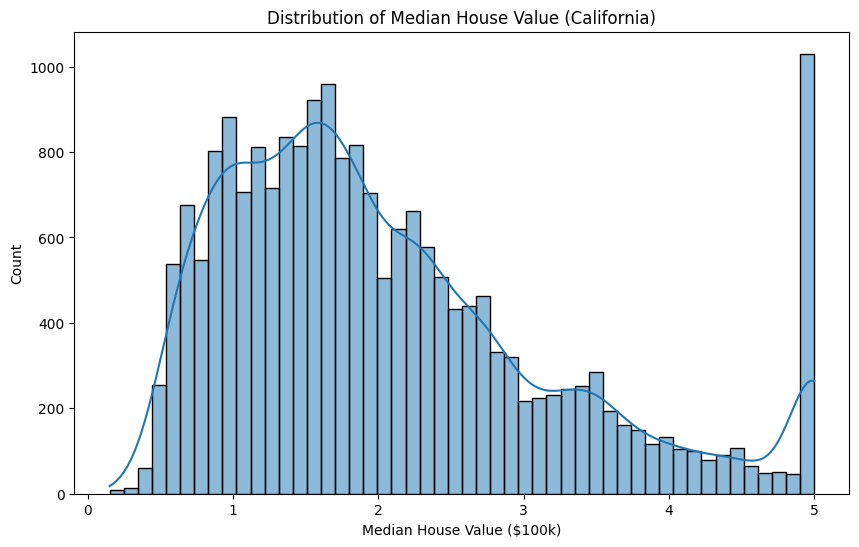

In [5]:
# EDA - California
plt.figure(figsize=(10, 6))
sns.histplot(df_cal['MedHouseVal'], bins=50, kde=True)
plt.title('Distribution of Median House Value (California)')
plt.xlabel('Median House Value ($100k)')
plt.show()

## 2. Ontario Housing Data
Source: We will simulate fetching this from an external source or create a synthetic dataset if a direct API for clean housing price data is unavailable for this workshop demo. 
*For the purpose of this workshop, to ensure we have a clean "Ontario-like" dataset, we will generate synthetic data that mimics Toronto housing characteristics (Price vs Size).* 

In [6]:
# Synthetic Ontario Data Generation (mimicking real characteristics)
# Price = 150000 + 400 * Size(sqft) + Noise
np.random.seed(42)
n_samples = 1000
sqft = np.random.normal(1500, 500, n_samples).astype(int)
sqft = sqft[sqft > 300] # filtering unrealistic sizes

price = 150000 + 400 * sqft + np.random.normal(0, 50000, len(sqft))

df_on = pd.DataFrame({'Size_sqft': sqft, 'Price_CAD': price})

# Save to CSV
df_on.to_csv('../data/raw/ontario_housing.csv', index=False)
print(f"Ontario Data Saved: {df_on.shape}")
df_on.head()

Ontario Data Saved: (994, 2)


,Size_sqft,Price_CAD
0,1748,9.191678e+05
1,1430,7.682317e+05
2,1823,8.821815e+05
3,2261,1.022053e+06
4,1382,7.377112e+05


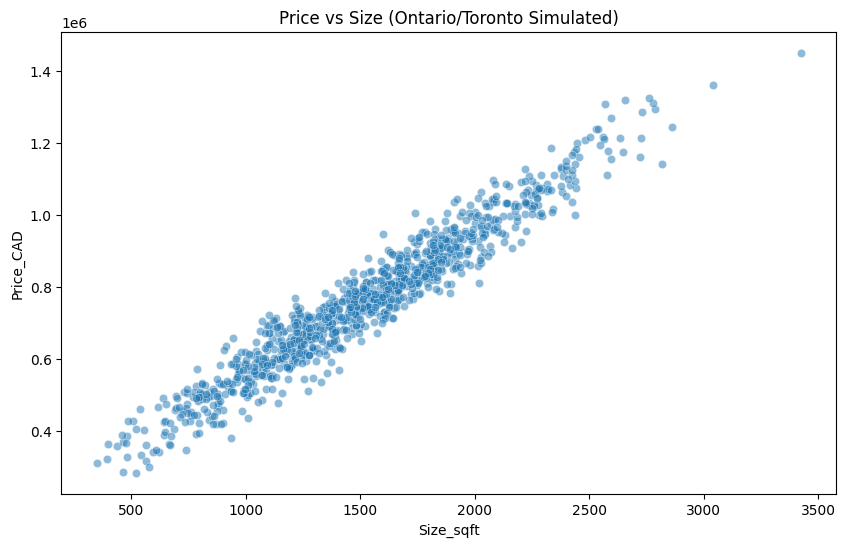

In [7]:
# EDA - Ontario
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_on['Size_sqft'], y=df_on['Price_CAD'], alpha=0.5)
plt.title('Price vs Size (Ontario/Toronto Simulated)')
plt.show()

## 3. Database Creation
Loading both datasets into a local SQLite database.

In [8]:
conn = sqlite3.connect('../data/housing.db')

df_cal.to_sql('california_housing', conn, if_exists='replace', index=False)
df_on.to_sql('ontario_housing', conn, if_exists='replace', index=False)

print("Data loaded into SQLite database: data/housing.db")
conn.close()

Data loaded into SQLite database: data/housing.db
